In [10]:
# 挂载 Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 切换到工作目录
import os
os.chdir('/content/drive/My Drive')

# 安装依赖
!pip install PyWavelets

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
# kmax 敏感性分析：训练多个不同 kmax 值的模型
kmax_values = [64]

for kmax in kmax_values:
    print(f"\n{'='*60}")
    print(f"Training FNPG with kmax = {kmax}")
    print(f"{'='*60}\n")

    !python /content/drive/MyDrive/logcompletion/code/fnpg_train.py \
        --kmax {kmax} \
        --output_dir /content/drive/MyDrive/logcompletion/model/kmax_sensitivity/ \
        --epochs 200 \
        --batch_size 600 \
        --lr 0.001 \
        --first_train

    print(f"\nCompleted kmax = {kmax}")


Training FNPG with kmax = 64

Loading tensor from file: /content/drive/MyDrive/logcompletion/data/Teamdata/complete_data_for_PIModel/train/Train_x_all_complete_15.9-15.pt
Loading tensor from file: /content/drive/MyDrive/logcompletion/data/Teamdata/complete_data_for_PIModel/train/Train_x_all_complete_15.9-17.pt
Loading tensor from file: /content/drive/MyDrive/logcompletion/data/Teamdata/complete_data_for_PIModel/train/Train_x_all_complete_16.1-2.pt
Loading tensor from file: /content/drive/MyDrive/logcompletion/data/Teamdata/complete_data_for_PIModel/train/Train_x_all_complete_16.1-6 A.pt
Loading tensor from file: /content/drive/MyDrive/logcompletion/data/Teamdata/complete_data_for_PIModel/train/Train_x_all_complete_16.10-1.pt
Loading tensor from file: /content/drive/MyDrive/logcompletion/data/Teamdata/complete_data_for_PIModel/train/Train_x_all_complete_16.10-2.pt
Loading tensor from file: /content/drive/MyDrive/logcompletion/data/Teamdata/complete_data_for_PIModel/train/Train_x_all_co

kmax=2: Final Test Loss = 0.445270
kmax=4: Final Test Loss = 0.319274
kmax=8: Final Test Loss = 0.230704


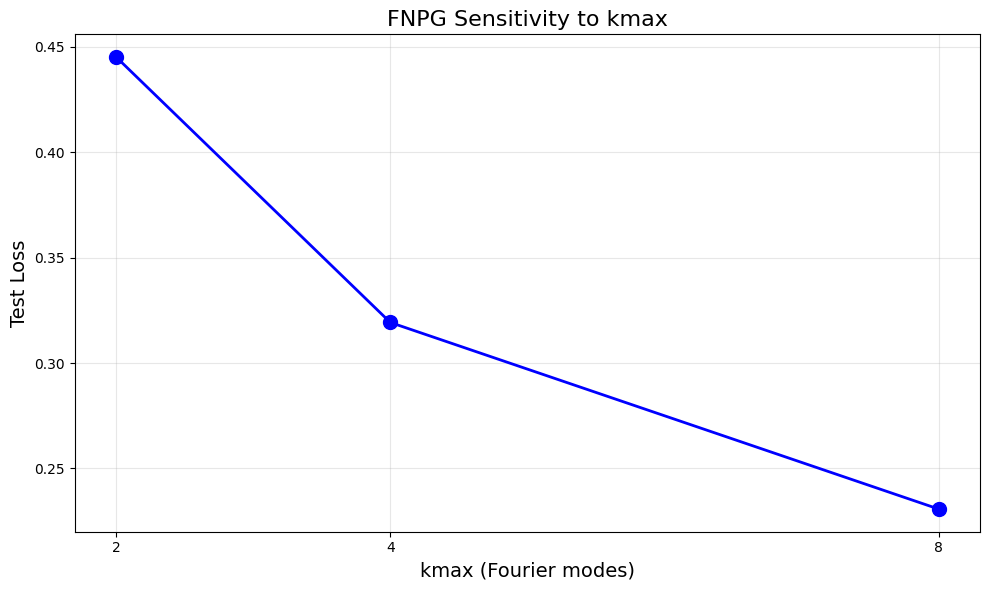

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

kmax_values = [2,4,8]
base_path = '/content/drive/MyDrive/logcompletion/model/kmax_sensitivity'

# 加载各 kmax 的最终测试 loss
final_test_losses = []
for kmax in kmax_values:
    loss_file = f'{base_path}/kmax_{kmax}/loss_kmax{kmax}_test.npy'
    try:
        losses = np.load(loss_file)
        final_test_losses.append(losses[-1])  # 最后一个 epoch 的 loss
        print(f"kmax={kmax}: Final Test Loss = {losses[-1]:.6f}")
    except FileNotFoundError:
        print(f"kmax={kmax}: Loss file not found")
        final_test_losses.append(None)

# 绘制 kmax vs Test Loss 曲线
plt.figure(figsize=(10, 6))
valid_kmax = [k for k, l in zip(kmax_values, final_test_losses) if l is not None]
valid_losses = [l for l in final_test_losses if l is not None]
plt.plot(valid_kmax, valid_losses, 'bo-', markersize=10, linewidth=2)
plt.xlabel('kmax (Fourier modes)', fontsize=14)
plt.ylabel('Test Loss', fontsize=14)
plt.title('FNPG Sensitivity to kmax', fontsize=16)
plt.grid(True, alpha=0.3)
plt.xticks(kmax_values)
plt.tight_layout()
plt.savefig(f'{base_path}/kmax_sensitivity_analysis.pdf')
plt.show()

kmax=2: Epochs=200, Final=0.4453, Best=0.4403, Max=6.1336
kmax=4: Epochs=200, Final=0.3193, Best=0.3191, Max=2.9802
kmax=8: Epochs=200, Final=0.2307, Best=0.2301, Max=0.9676
kmax=16: Epochs=200, Final=0.1862, Best=0.1850, Max=1.1442
kmax=32: Epochs=200, Final=0.1434, Best=0.1417, Max=0.9099



/tmp/ipython-input-2769682338.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



Figures saved:
  PDF: /content/drive/MyDrive/logcompletion/model/kmax_sensitivity/kmax_ablation_experiment_2-32.pdf
  PNG: /content/drive/MyDrive/logcompletion/model/kmax_sensitivity/kmax_ablation_experiment_2-32.png


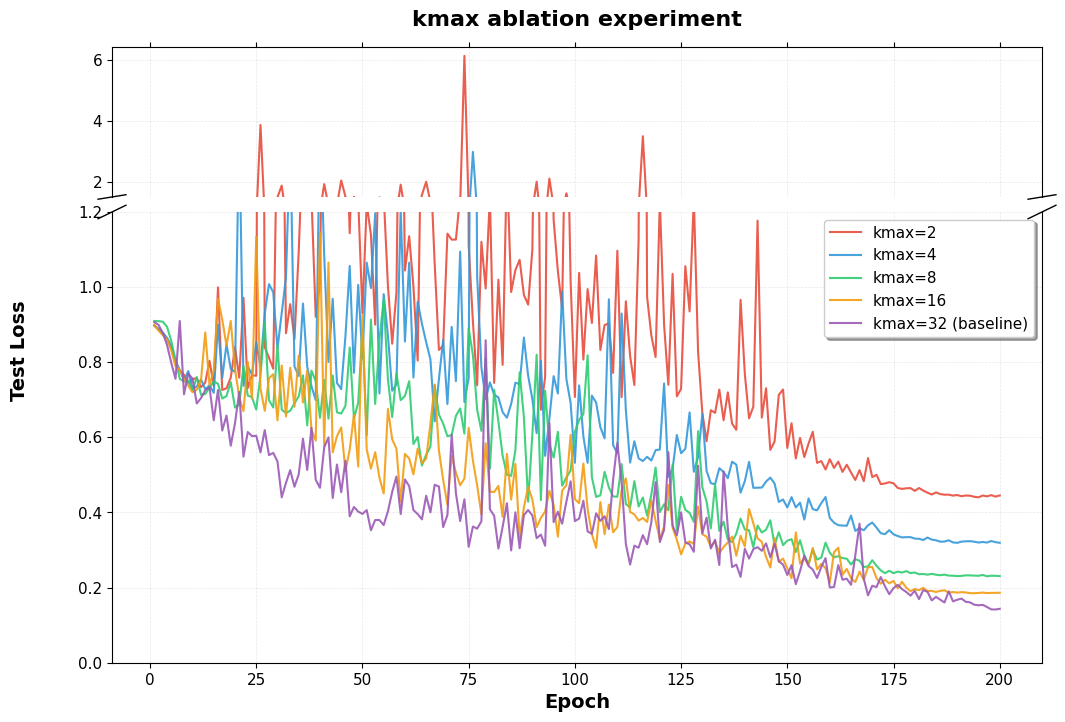

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches

# 配置
kmax_values = [2, 4, 8, 16, 32]
base_path = '/content/drive/MyDrive/logcompletion/model/kmax_sensitivity'

# 美观的配色方案
# 美观的配色方案
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']
linewidths = [1.5, 1.5, 1.5, 1.5, 1.5]

# 加载所有数据
loss_data = {}
for kmax in kmax_values:
    if kmax == 32:
        loss_file = '/content/drive/MyDrive/logcompletion/metrics/test_loss_epoch200_vnila.npy（副本）'
    else:
        loss_file = f'{base_path}/kmax_{kmax}/loss_kmax{kmax}_test.npy'

    try:
        losses = np.load(loss_file)
        loss_data[kmax] = losses
        print(f"kmax={kmax}: Epochs={len(losses)}, "
              f"Final={losses[-1]:.4f}, Best={losses.min():.4f}, "
              f"Max={losses.max():.4f}")
    except FileNotFoundError:
        print(f"kmax={kmax}: File not found")

print("\n" + "="*60)

# 创建断轴图形：上下两个子图
fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(12, 8),gridspec_kw={'height_ratios': [1, 3],'hspace': 0.05})

# 定义Y轴范围
y_bottom_max = 1.2  # 下方子图的上限
y_top_min = 1.5# 上方子图的下限（留一点gap）

# 绘制曲线到两个子图
for idx, kmax in enumerate(kmax_values):
    if kmax not in loss_data:
        continue

    losses = loss_data[kmax]
    epochs = np.arange(1, len(losses) + 1)

    label = f'kmax={kmax} (baseline)' if kmax == 32 else f'kmax={kmax}'

    # 在两个子图上都绘制
    ax_top.plot(epochs, losses, color=colors[idx],
                linewidth=linewidths[idx], label=label, alpha=0.9)
    ax_bottom.plot(epochs, losses, color=colors[idx],
                    linewidth=linewidths[idx], label=label, alpha=0.9)

# 设置Y轴范围
ax_bottom.set_ylim(0, y_bottom_max)
ax_top.set_ylim(y_top_min, None)  # 自动调整上限

# 隐藏上方子图的X轴标签和下方子图的顶部边框
ax_top.spines['bottom'].set_visible(False)
ax_bottom.spines['top'].set_visible(False)
ax_top.xaxis.tick_top()
ax_top.tick_params(labeltop=False)
ax_bottom.xaxis.tick_bottom()


# 添加断裂标记（斜线）
d = 0.015  # 斜线的大小
kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False, linewidth=1)
ax_top.plot((-d, +d), (-d, +d), **kwargs)        # 左下斜线
ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # 右下斜线

kwargs.update(transform=ax_bottom.transAxes)
ax_bottom.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # 左上斜 线
ax_bottom.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  #  右上斜线

# 设置标签和标题
ax_bottom.set_xlabel('Epoch', fontsize=14, fontweight='bold')
fig.text(0.04, 0.5, 'Test Loss', va='center', rotation='vertical',
          fontsize=14, fontweight='bold')
ax_top.set_title('kmax ablation experiment', fontsize=16, fontweight='bold', pad=15)

# 网格
ax_top.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax_bottom.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

# 图例（只在下方子图显示）
ax_bottom.legend(loc='upper right', fontsize=11, frameon=True,shadow=True, fancybox=True)

# 刻度标签大小
ax_top.tick_params(axis='both', which='major', labelsize=11)
ax_bottom.tick_params(axis='both', which='major', labelsize=11)

# 保存图片
plt.tight_layout()
output_pdf = f'{base_path}/kmax_ablation_experiment_2-32.pdf'
output_png = f'{base_path}/kmax_ablation_experiment_2-32.png'
plt.savefig(output_pdf, dpi=300, bbox_inches='tight')
plt.savefig(output_png, dpi=300, bbox_inches='tight')

print(f"\n{'='*60}")
print(f"Figures saved:")
print(f"  PDF: {output_pdf}")
print(f"  PNG: {output_png}")
print(f"{'='*60}")

plt.show()

In [3]:
# get reconstruction matrics
import numpy as np

kmax_values = [2, 4, 8, 16, 32]
base_path = '/content/drive/MyDrive/logcompletion/model/kmax_sensitivity'

print("=" * 70)
print("kmax Ablation Study - Final Metrics")
print("=" * 70)
print(f"{'kmax':<6} {'Final Loss':<12} {'Best Loss':<12} {'Epoch to Best':<15}")
print("-" * 70)

results = {}
for kmax in kmax_values:
    if kmax == 16:
        loss_file = '/content/drive/MyDrive/logcompletion/metrics/test_loss_epoch200_vnila.npy（副本）'
    else:
        loss_file = f'{base_path}/kmax_{kmax}/loss_kmax{kmax}_test.npy'

    losses = np.load(loss_file)
    final_loss = losses[-1]
    best_loss = losses.min()
    best_epoch = losses.argmin() + 1

    results[kmax] = {
        'final': final_loss,
        'best': best_loss,
        'epoch': best_epoch
    }

    print(f"{kmax:<6} {final_loss:<12.6f} {best_loss:<12.6f} {best_epoch:<15}")

print("=" * 70)

# Calculate performance comparisons
print("\nPerformance Comparisons:")
print(f"kmax=2 vs kmax=16: {results[16]['best']/results[2]['best']:.2f}x better")
print(f"kmax=4 vs kmax=16: {results[16]['best']/results[4]['best']:.2f}x better")
print(f"kmax=8 vs kmax=16: {results[16]['best']/results[8]['best']:.2f}x better")

kmax Ablation Study - Final Metrics
kmax   Final Loss   Best Loss    Epoch to Best  
----------------------------------------------------------------------
2      0.445270     0.440257     195            
4      0.319274     0.319065     190            
8      0.230704     0.230058     197            
16     0.143415     0.141658     199            

Performance Comparisons:
kmax=2 vs kmax=16: 0.32x better
kmax=4 vs kmax=16: 0.44x better
kmax=8 vs kmax=16: 0.62x better


FNPG kmax Sensitivity Evaluation
Device: cuda
kmax values to evaluate: [2, 4, 8, 16, 32]
Loading data...
Test data shape: input=torch.Size([34, 4, 512]), target=torch.Size([34, 5, 512])

Evaluating kmax=2
Loaded model from epoch 193, val_loss=0.443230
Total parameters: 6,844,549
Running inference...


100%|██████████| 17/17 [00:00<00:00, 35.50it/s]



Evaluating kmax=4
Loaded model from epoch 192, val_loss=0.321881
Total parameters: 7,270,533
Running inference...


100%|██████████| 17/17 [00:00<00:00, 34.33it/s]



Evaluating kmax=8
Loaded model from epoch 197, val_loss=0.230977
Total parameters: 8,122,501
Running inference...


...


Evaluating kmax=16
Loaded model from epoch 192, val_loss=0.186202
Total parameters: 9,826,437
Running inference...


100%|██████████| 17/17 [00:00<00:00, 37.56it/s]



Evaluating kmax=32
Loaded model from epoch 197, val_loss=0.148830
Total parameters: 13,234,309
Running inference...


100%|██████████| 17/17 [00:00<00:00, 37.19it/s]



kmax Ablation Study - Complete Metrics Summary
kmax   Params       Test Loss    MSE          RMSE       MAE        R²         Pearson R 
----------------------------------------------------------------------------------------------------
2      6,844,549    0.445270     0.389152     0.623820   0.470137   0.595150   0.772946  
4      7,270,533    0.319274     0.272869     0.522368   0.384706   0.716124   0.846309  
8      8,122,501    0.230704     0.185255     0.430413   0.319132   0.807272   0.898593  
16     9,826,437    0.186232     0.143166     0.378373   0.282801   0.851059   0.922644  
32     13,234,309   0.144740     0.105335     0.324554   0.245623   0.890415   0.943699  

Performance Comparisons (relative to kmax=16):
------------------------------------------------------------
kmax= 2 vs kmax=16: MSE ratio=2.7182x, R² diff=-0.255909
kmax= 4 vs kmax=16: MSE ratio=1.9060x, R² diff=-0.134935
kmax= 8 vs kmax=16: MSE ratio=1.2940x, R² diff=-0.043787
kmax=32 vs kmax=16: MSE ratio=0

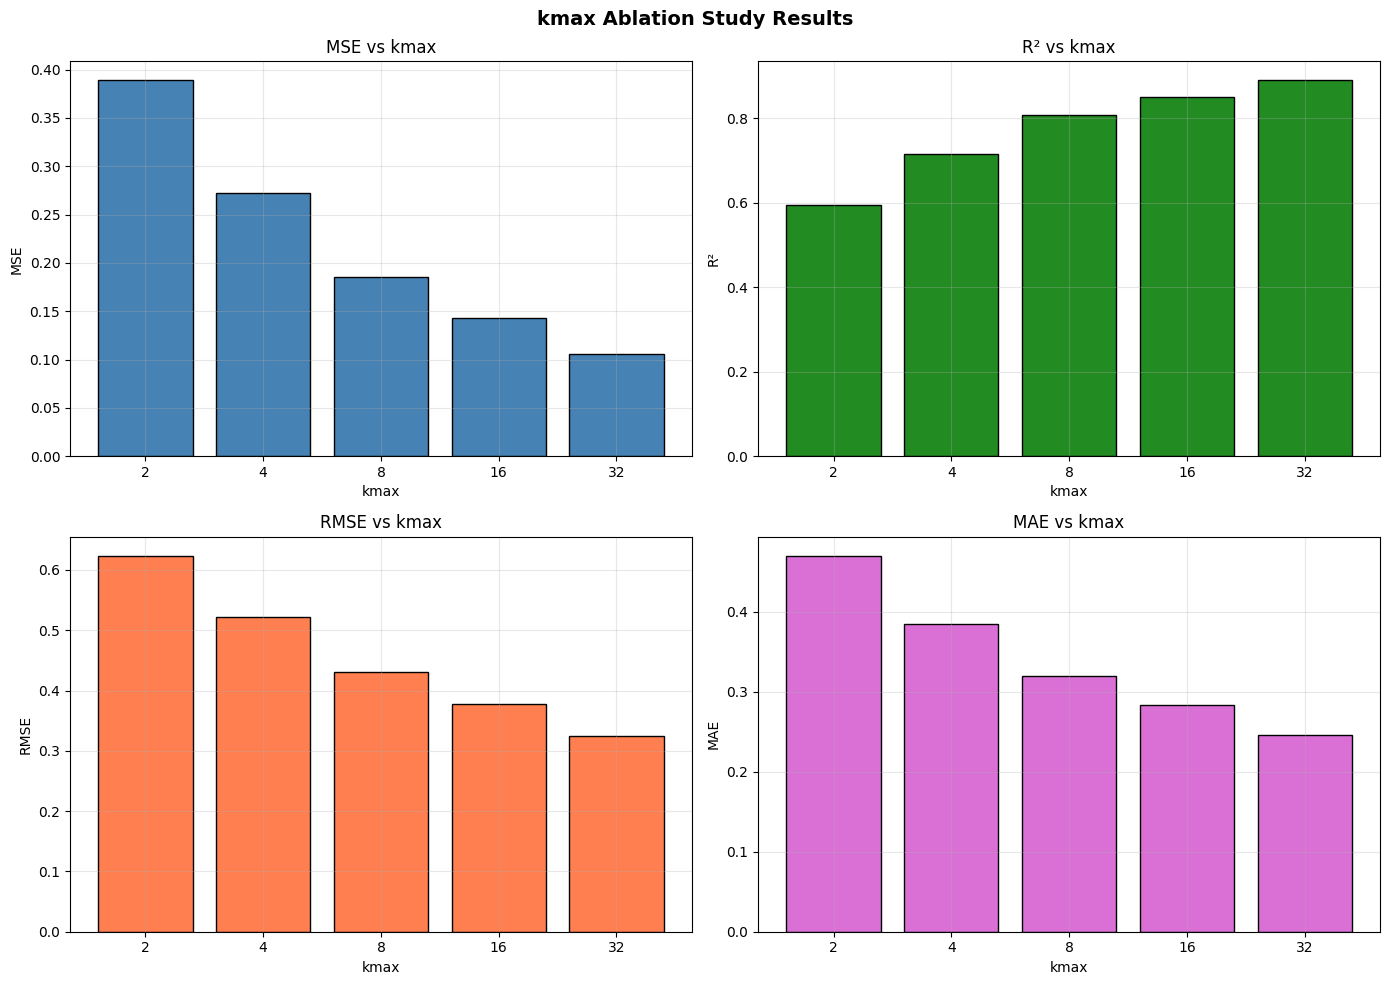


Evaluation Complete!


<Figure size 640x480 with 0 Axes>

In [17]:
%run /content/drive/MyDrive/logcompletion/code/kmax_evaluation.py

In [25]:
# get parameters in different kmax
# 只导入需要的类，不执行整个脚本
import sys
sys.path.append('/content/drive/MyDrive/logcompletion/code')

import torch
import torch.nn as nn
import torch.nn.functional as F
from functools import reduce
import operator

# 直接定义FNPG需要的核心组件（从fnpg_train.py复制关键类）
# 这样可以避免执行argparse和数据加载代码

class SpectralConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1):
        super(SpectralConv1d, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.scale = (1 / (in_channels * out_channels))
        self.weights1 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, dtype=torch.cfloat))
        self.weights3 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, dtype=torch.cfloat))
        self.weights4 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, dtype=torch.cfloat))

    def compl_mul1d(self, input, weights):
        return torch.einsum("bix,iox->box", input, weights)

    def forward(self, x):
        batchsize = x.shape[0]
        x_ft = torch.fft.rfftn(x, dim=[-1]).to(x.device)
        out_ft = torch.zeros(batchsize, self.out_channels, x.size(-1)//2 + 1, dtype=torch.cfloat, device=x.device)
        out_ft[:, :, :self.modes1] = self.compl_mul1d(x_ft[:, :, :self.modes1], self.weights1.to(x.device))
        out_ft[:, :, -self.modes1:] = self.compl_mul1d(x_ft[:, :, -self.modes1:], self.weights2.to(x.device))
        out_ft[:, :, :self.modes1] = self.compl_mul1d(x_ft[:, :, :self.modes1], self.weights3.to(x.device))
        out_ft[:, :, -self.modes1:] = self.compl_mul1d(x_ft[:, :, -self.modes1:], self.weights4.to(x.device))
        x = torch.fft.irfftn(out_ft, s=(x.size(-1)))
        return x

class MLP_(nn.Module):
    def __init__(self, in_channels, out_channels, mid_channels):
        super(MLP_, self).__init__()
        self.mlp1 = nn.Conv1d(in_channels, mid_channels, 1)
        self.mlp2 = nn.Conv1d(mid_channels, out_channels, 1)

    def forward(self, x):
        x = self.mlp1(x)
        x = F.gelu(x)
        x = self.mlp2(x)
        return x

class FourierFeatureExtractor(nn.Module):
    def __init__(self, in_channels=4, out_channels=1, mid_channels=8, modes1=8):
        super(FourierFeatureExtractor, self).__init__()
        self.fconv1 = SpectralConv1d(in_channels, mid_channels, modes1)
        self.fconv2 = SpectralConv1d(mid_channels, mid_channels, modes1)
        self.fconv3 = SpectralConv1d(mid_channels, mid_channels, modes1)
        self.mlp1 = MLP_(mid_channels, mid_channels, mid_channels)
        self.mlp2 = MLP_(mid_channels, mid_channels, mid_channels)
        self.mlp3 = MLP_(mid_channels, mid_channels, mid_channels)
        self.w1 = nn.Conv1d(in_channels, mid_channels, 1)
        self.w2 = nn.Conv1d(mid_channels, mid_channels, 1)
        self.w3 = nn.Conv1d(mid_channels, mid_channels, 1)
        self.out_proj = MLP_(mid_channels, out_channels, mid_channels)

    def forward(self, x):
        x_f = self.fconv1(x)
        x_f = self.mlp1(x_f)
        x_c = self.w1(x)
        x = x_f + x_c
        x = F.gelu(x)
        x_f = self.fconv2(x)
        x_f = self.mlp2(x_f)
        x_c = self.w2(x)
        x = x_f + x_c
        x = F.gelu(x)
        x_f = self.fconv3(x)
        x_f = self.mlp3(x_f)
        x_c = self.w3(x)
        x = x_f + x_c
        x = F.gelu(x)
        x = self.out_proj(x)
        return x

def count_params(model):
    c = 0
    for p in list(model.parameters()):
        c += reduce(operator.mul, list(p.size()+(2,) if p.is_complex() else p.size()))
    return c

# 计算不同kmax的参数量
print("=" * 70)
print("Model Parameters by kmax (FFE modules only)")
print("=" * 70)

param_counts = {}
for kmax in [2, 4, 8, 16, 32]:
    # 创建单个FFE模块来计算其参数
    ffe = FourierFeatureExtractor(in_channels=32, out_channels=32, mid_channels=32, modes1=kmax)
    params = count_params(ffe)
    param_counts[kmax] = params
    print(f"kmax = {kmax:2d}: {params:,} parameters per FFE")

print("=" * 70)
print("\nFNPG uses 6 FFE modules, so total FFE parameters:")
for kmax in [2, 4, 8, 16]:
    total = param_counts[kmax] * 6
    print(f"kmax = {kmax:2d}: {total:,} parameters (6 FFEs)")

print("\n" + "=" * 70)
print("Parameter Comparison (relative to kmax=16):")
print("=" * 70)
baseline = param_counts[16] * 6
for kmax in [2, 4, 8]:
    total = param_counts[kmax] * 6
    diff = baseline - total
    pct = (diff / total) * 100
    print(f"kmax=16 has {diff:,} more FFE parameters than kmax={kmax} (+{pct:.1f}%)")

Model Parameters by kmax (FFE modules only)
kmax =  2: 60,768 parameters per FFE
kmax =  4: 109,920 parameters per FFE
kmax =  8: 208,224 parameters per FFE
kmax = 16: 404,832 parameters per FFE
kmax = 32: 798,048 parameters per FFE

FNPG uses 6 FFE modules, so total FFE parameters:
kmax =  2: 364,608 parameters (6 FFEs)
kmax =  4: 659,520 parameters (6 FFEs)
kmax =  8: 1,249,344 parameters (6 FFEs)
kmax = 16: 2,428,992 parameters (6 FFEs)

Parameter Comparison (relative to kmax=16):
kmax=16 has 2,064,384 more FFE parameters than kmax=2 (+566.2%)
kmax=16 has 1,769,472 more FFE parameters than kmax=4 (+268.3%)
kmax=16 has 1,179,648 more FFE parameters than kmax=8 (+94.4%)
